# Semantic Reembedding — Slide Diagrams

Three figures for the presentation slide on `f_semantic_reembed.py`.
Run each cell and export the figure as PNG (`fig.savefig(...)` at the end of each cell).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
from matplotlib.colors import LinearSegmentedColormap

# Shared palette
C_BLUE   = '#2D6BE4'
C_ORANGE = '#E87C2A'
C_GREEN  = '#27AE60'
C_RED    = '#E03E3E'
C_GRAY   = '#8A8A8A'
C_LIGHT  = '#F5F6FA'
C_DARK   = '#1A1A2E'

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
})

## Figure 1 — Pipeline flowchart

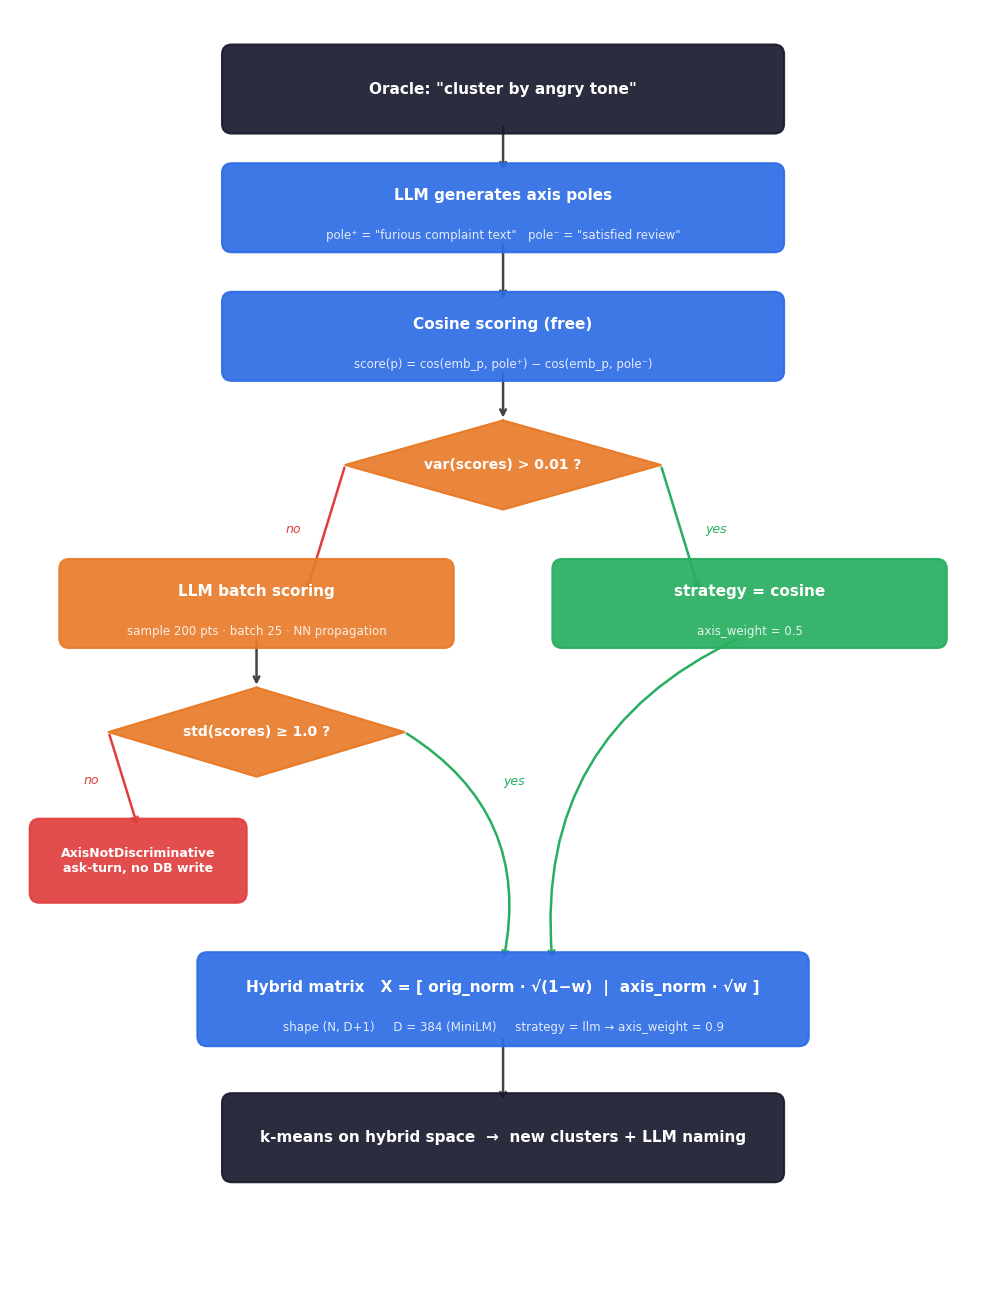

In [ ]:
fig, ax = plt.subplots(figsize=(10, 13))
ax.set_xlim(0, 10)
ax.set_ylim(0, 13)
ax.axis('off')

def box(ax, x, y, w, h, text, color, textcolor='white', fontsize=11, style='round,pad=0.1', sub=None):
    bbox = FancyBboxPatch((x - w/2, y - h/2), w, h,
                          boxstyle=style, linewidth=1.5,
                          edgecolor=color, facecolor=color, alpha=0.92, zorder=3)
    ax.add_patch(bbox)
    ax.text(x, y + (0.12 if sub else 0), text, ha='center', va='center',
            fontsize=fontsize, color=textcolor, fontweight='bold', zorder=4)
    if sub:
        ax.text(x, y - 0.28, sub, ha='center', va='center',
                fontsize=8.5, color=textcolor, alpha=0.85, zorder=4)

def diamond(ax, x, y, w, h, text, color, fontsize=10):
    dx, dy = w/2, h/2
    xs = [x, x+dx, x, x-dx, x]
    ys = [y+dy, y, y-dy, y, y+dy]
    ax.fill(xs, ys, color=color, alpha=0.92, zorder=3)
    ax.plot(xs, ys, color=color, lw=1.5, zorder=4)
    ax.text(x, y, text, ha='center', va='center',
            fontsize=fontsize, color='white', fontweight='bold', zorder=5)

def arrow(ax, x1, y1, x2, y2, label=None, label_side='right', color='#444'):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.8), zorder=2)
    if label:
        mx, my = (x1+x2)/2, (y1+y2)/2
        offset = 0.25 if label_side == 'right' else -0.25
        ax.text(mx + offset, my, label, ha='left' if label_side == 'right' else 'right',
                va='center', fontsize=9, color=color, style='italic')

Y_INPUT   = 12.2
Y_POLES   = 11.0
Y_COSINE  = 9.7
Y_DIAMOND = 8.4
Y_USE_COS = 7.0
Y_LLM     = 7.0
Y_DIA2    = 5.7
Y_ERROR   = 4.4
Y_MATRIX  = 3.0
Y_KMEANS  = 1.6

X_C  = 5.0
X_R  = 7.5
X_L  = 2.5

box(ax, X_C, Y_INPUT, 5.5, 0.7, 'Oracle: "cluster by angry tone"', C_DARK, fontsize=11)
box(ax, X_C, Y_POLES, 5.5, 0.7, 'LLM generates axis poles', C_BLUE,
    sub='pole⁺ = "furious complaint text"   pole⁻ = "satisfied review"')
box(ax, X_C, Y_COSINE, 5.5, 0.7, 'Cosine scoring (free)', C_BLUE,
    sub='score(p) = cos(emb_p, pole⁺) − cos(emb_p, pole⁻)')
diamond(ax, X_C, Y_DIAMOND, 3.2, 0.9, 'var(scores) > 0.01 ?', C_ORANGE)
box(ax, X_R, Y_USE_COS, 3.8, 0.7, 'strategy = cosine', C_GREEN, sub='axis_weight = 0.5')
box(ax, X_L, Y_LLM, 3.8, 0.7, 'LLM batch scoring', C_ORANGE,
    sub='sample 200 pts · batch 25 · NN propagation')
diamond(ax, X_L, Y_DIA2, 3.0, 0.9, 'std(scores) ≥ 1.0 ?', C_ORANGE)
box(ax, X_L - 1.2, Y_ERROR, 2.0, 0.65,
    'AxisNotDiscriminative\nask-turn, no DB write', C_RED, fontsize=9)
box(ax, X_C, Y_MATRIX, 6.0, 0.75,
    'Hybrid matrix   X = [ orig_norm · √(1−w)  |  axis_norm · √w ]', C_BLUE,
    sub='shape (N, D+1)     D = 384 (MiniLM)     strategy = llm → axis_weight = 0.9')
box(ax, X_C, Y_KMEANS, 5.5, 0.7,
    'k-means on hybrid space  →  new clusters + LLM naming', C_DARK)

arrow(ax, X_C, Y_INPUT-0.35, X_C, Y_POLES+0.35)
arrow(ax, X_C, Y_POLES-0.35, X_C, Y_COSINE+0.35)
arrow(ax, X_C, Y_COSINE-0.35, X_C, Y_DIAMOND+0.45)
arrow(ax, X_C+1.6, Y_DIAMOND, X_R-0.5, Y_USE_COS+0.1, label='yes', color=C_GREEN)
arrow(ax, X_C-1.6, Y_DIAMOND, X_L+0.5, Y_LLM+0.1, label='no', label_side='left', color=C_RED)
arrow(ax, X_L, Y_LLM-0.35, X_L, Y_DIA2+0.45)
arrow(ax, X_L-1.5, Y_DIA2, X_L-1.2, Y_ERROR+0.33, label='no', label_side='left', color=C_RED)
ax.annotate('', xy=(X_C, Y_MATRIX+0.38), xytext=(X_L+1.5, Y_DIA2),
            arrowprops=dict(arrowstyle='->', color=C_GREEN, lw=1.8,
                            connectionstyle='arc3,rad=-0.35'), zorder=2)
ax.text(X_L+2.5, Y_DIA2-0.5, 'yes', ha='left', va='center', fontsize=9, color=C_GREEN, style='italic')
ax.annotate('', xy=(X_C+0.5, Y_MATRIX+0.38), xytext=(X_R-0.1, Y_USE_COS-0.35),
            arrowprops=dict(arrowstyle='->', color=C_GREEN, lw=1.8,
                            connectionstyle='arc3,rad=0.35'), zorder=2)
arrow(ax, X_C, Y_MATRIX-0.38, X_C, Y_KMEANS+0.35)

fig.tight_layout(pad=0.5)
fig.savefig('fig1_pipeline.png', dpi=150, bbox_inches='tight')
plt.show()

## Figure 2 — MiniLM embedding space with axis

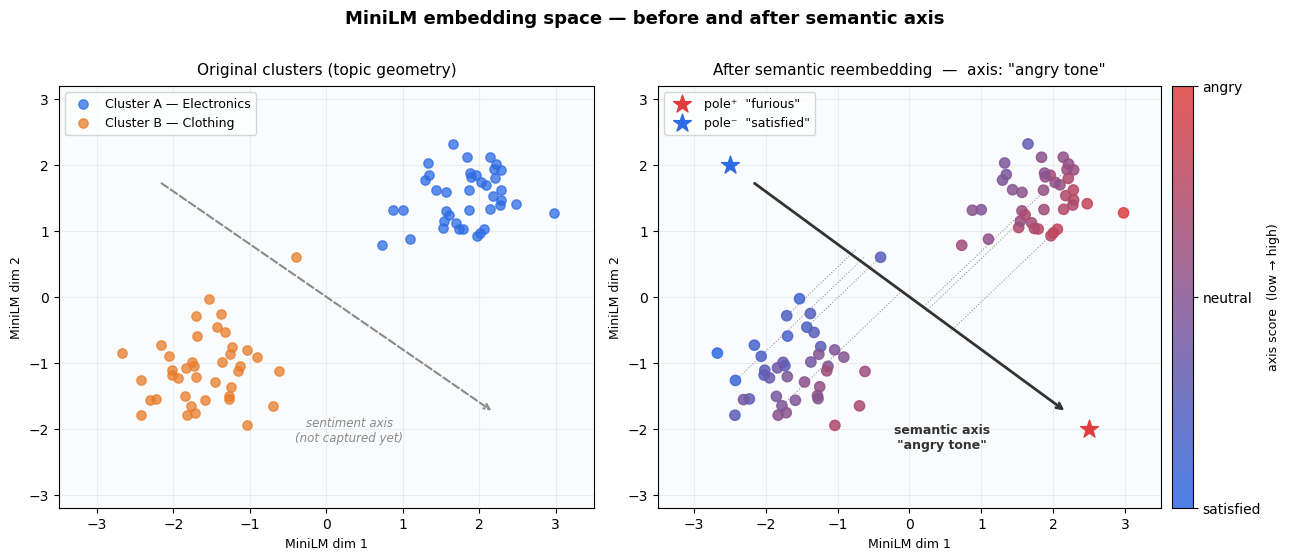

In [ ]:
rng = np.random.default_rng(42)

n = 80
topic_A = rng.normal([1.8, 1.5], 0.55, (n//2, 2))
topic_B = rng.normal([-1.5, -1.0], 0.55, (n//2, 2))
points = np.vstack([topic_A, topic_B])

axis_dir = np.array([0.72, -0.69])
axis_dir /= np.linalg.norm(axis_dir)
sentiment = points @ axis_dir + rng.normal(0, 0.15, n)
sentiment = (sentiment - sentiment.min()) / (sentiment.max() - sentiment.min())

pole_pos = np.array([2.5, -2.0])
pole_neg = np.array([-2.5, 2.0])

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
fig.suptitle('MiniLM embedding space — before and after semantic axis',
             fontsize=13, fontweight='bold', y=1.01)

ax = axes[0]
ax.set_title('Original clusters (topic geometry)', fontsize=11, pad=8)
ax.scatter(points[:n//2, 0], points[:n//2, 1], c=C_BLUE,   s=45, alpha=0.75,
           label='Cluster A — Electronics', zorder=3)
ax.scatter(points[n//2:, 0], points[n//2:, 1], c=C_ORANGE, s=45, alpha=0.75,
           label='Cluster B — Clothing', zorder=3)
scale = 2.8
ax.annotate('', xy=pole_pos/np.linalg.norm(pole_pos)*scale,
            xytext=pole_neg/np.linalg.norm(pole_neg)*scale,
            arrowprops=dict(arrowstyle='->', color=C_GRAY, lw=1.5, linestyle='dashed'))
ax.text(0.3, -2.2, 'sentiment axis\n(not captured yet)', fontsize=8.5,
        color=C_GRAY, ha='center', style='italic')
ax.set_xlim(-3.5, 3.5); ax.set_ylim(-3.2, 3.2)
ax.legend(fontsize=9, loc='upper left')
ax.set_xlabel('MiniLM dim 1', fontsize=9); ax.set_ylabel('MiniLM dim 2', fontsize=9)
ax.grid(True, alpha=0.2); ax.set_facecolor('#FAFBFD')

ax = axes[1]
ax.set_title('After semantic reembedding  —  axis: "angry tone"', fontsize=11, pad=8)
cmap = LinearSegmentedColormap.from_list('sentiment', ['#2D6BE4', '#E03E3E'])
sc = ax.scatter(points[:, 0], points[:, 1], c=sentiment, cmap=cmap,
                s=55, alpha=0.85, zorder=3, vmin=0, vmax=1)
ax.scatter(*pole_pos, s=180, c=C_RED,  marker='*', zorder=5, label='pole⁺  "furious"')
ax.scatter(*pole_neg, s=180, c=C_BLUE, marker='*', zorder=5, label='pole⁻  "satisfied"')
ax.annotate('', xy=pole_pos/np.linalg.norm(pole_pos)*scale,
            xytext=pole_neg/np.linalg.norm(pole_neg)*scale,
            arrowprops=dict(arrowstyle='->', color='#333', lw=2.0))
ax.text(0.45, -2.3, 'semantic axis\n"angry tone"', fontsize=9,
        color='#333', ha='center', fontweight='bold')
for i in rng.choice(n, 8, replace=False):
    p = points[i]
    proj_pt = (p @ axis_dir) * axis_dir
    ax.plot([p[0], proj_pt[0]], [p[1], proj_pt[1]], color='#999', lw=0.8, linestyle=':', zorder=2)
cbar = fig.colorbar(sc, ax=ax, fraction=0.04, pad=0.02)
cbar.set_label('axis score  (low → high)', fontsize=9)
cbar.set_ticks([0, 0.5, 1]); cbar.set_ticklabels(['satisfied', 'neutral', 'angry'])
ax.set_xlim(-3.5, 3.5); ax.set_ylim(-3.2, 3.2)
ax.legend(fontsize=9, loc='upper left')
ax.set_xlabel('MiniLM dim 1', fontsize=9); ax.set_ylabel('MiniLM dim 2', fontsize=9)
ax.grid(True, alpha=0.2); ax.set_facecolor('#FAFBFD')

fig.tight_layout()
fig.savefig('fig2_embedding_space.png', dpi=150, bbox_inches='tight')
plt.show()

## Figure 3 — Variance check: cosine ok vs LLM fallback

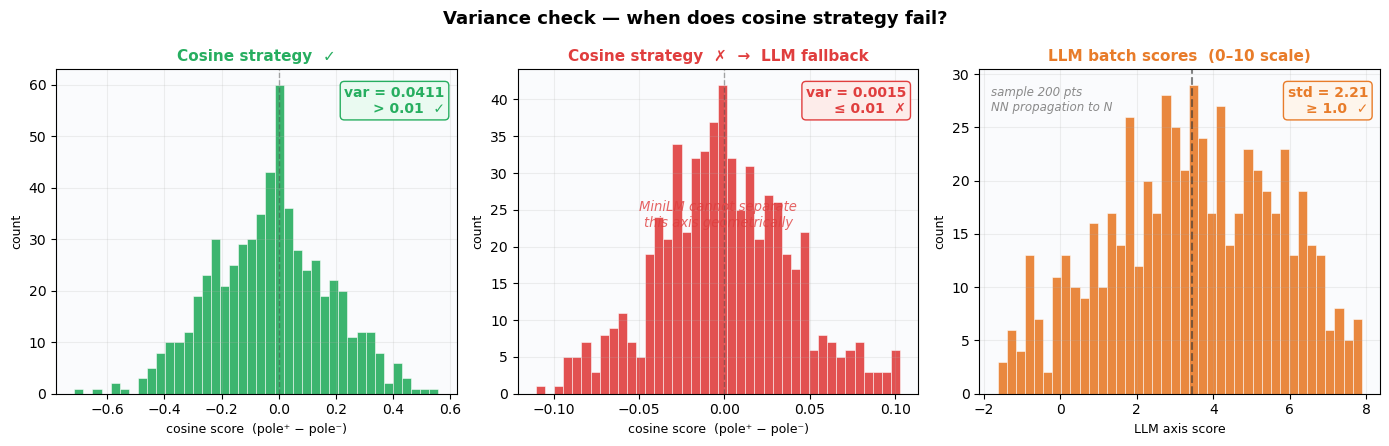

In [ ]:
rng = np.random.default_rng(7)

scores_wide   = rng.normal(0, 0.22, 600)
scores_narrow = rng.normal(0, 0.04, 600)
scores_llm    = rng.beta(2.2, 1.8, 600) * 10 - 2

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
fig.suptitle('Variance check — when does cosine strategy fail?', fontsize=13, fontweight='bold')
hist_kw = dict(bins=40, edgecolor='white', linewidth=0.4, alpha=0.9)

ax = axes[0]
ax.set_title('Cosine strategy  ✓', fontsize=11, color=C_GREEN, fontweight='bold')
ax.hist(scores_wide, **hist_kw, color=C_GREEN)
ax.axvline(0, color='#333', lw=1, linestyle='--', alpha=0.4)
ax.text(0.97, 0.95, f'var = {np.var(scores_wide):.4f}\n> 0.01  ✓',
        transform=ax.transAxes, ha='right', va='top', fontsize=10, color=C_GREEN, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#eafaf1', edgecolor=C_GREEN))
ax.set_xlabel('cosine score  (pole⁺ − pole⁻)', fontsize=9); ax.set_ylabel('count', fontsize=9)
ax.set_facecolor('#FAFBFD'); ax.grid(True, alpha=0.2)

ax = axes[1]
ax.set_title('Cosine strategy  ✗  →  LLM fallback', fontsize=11, color=C_RED, fontweight='bold')
ax.hist(scores_narrow, **hist_kw, color=C_RED)
ax.axvline(0, color='#333', lw=1, linestyle='--', alpha=0.4)
ax.text(0.97, 0.95, f'var = {np.var(scores_narrow):.4f}\n≤ 0.01  ✗',
        transform=ax.transAxes, ha='right', va='top', fontsize=10, color=C_RED, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#fdecea', edgecolor=C_RED))
ax.text(0.5, 0.55, 'MiniLM cannot separate\nthis axis geometrically',
        transform=ax.transAxes, ha='center', va='center', fontsize=9.5, color=C_RED, style='italic', alpha=0.8)
ax.set_xlabel('cosine score  (pole⁺ − pole⁻)', fontsize=9); ax.set_ylabel('count', fontsize=9)
ax.set_facecolor('#FAFBFD'); ax.grid(True, alpha=0.2)

ax = axes[2]
ax.set_title('LLM batch scores  (0–10 scale)', fontsize=11, color=C_ORANGE, fontweight='bold')
ax.hist(scores_llm, **hist_kw, color=C_ORANGE)
ax.axvline(scores_llm.mean(), color='#333', lw=1.5, linestyle='--', alpha=0.6)
ax.text(0.97, 0.95, f'std = {np.std(scores_llm):.2f}\n≥ 1.0  ✓',
        transform=ax.transAxes, ha='right', va='top', fontsize=10, color=C_ORANGE, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#fef5ec', edgecolor=C_ORANGE))
ax.text(0.03, 0.95, 'sample 200 pts\nNN propagation to N',
        transform=ax.transAxes, ha='left', va='top', fontsize=8.5, color=C_GRAY, style='italic')
ax.set_xlabel('LLM axis score', fontsize=9); ax.set_ylabel('count', fontsize=9)
ax.set_facecolor('#FAFBFD'); ax.grid(True, alpha=0.2)

fig.tight_layout()
fig.savefig('fig3_variance_check.png', dpi=150, bbox_inches='tight')
plt.show()

## Figure 4 — Hybrid matrix construction

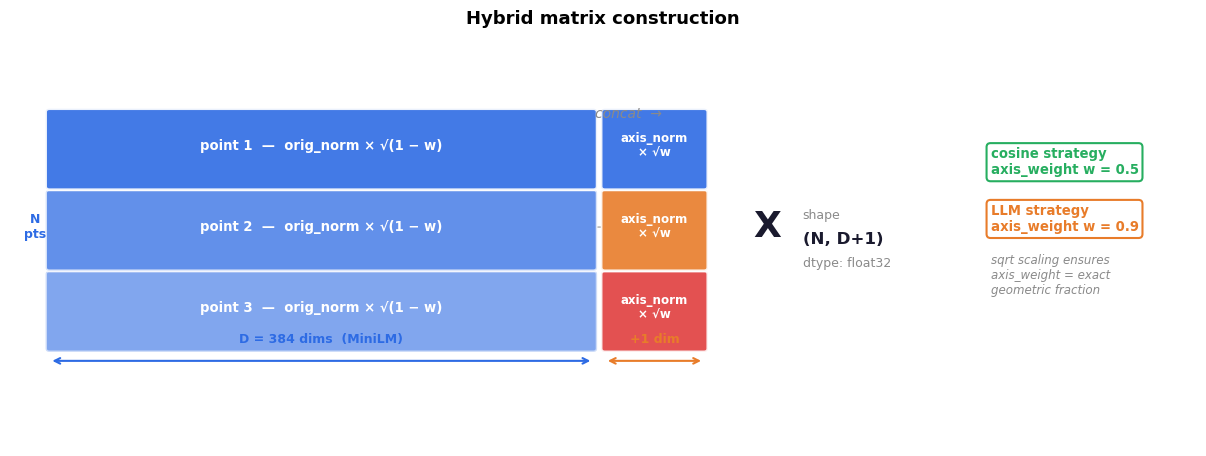

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.set_xlim(0, 12); ax.set_ylim(0, 5); ax.axis('off')
ax.set_title('Hybrid matrix construction', fontsize=13, fontweight='bold', pad=12)

def brace_label2(ax, x1, x2, y, text, color='#333'):
    ax.annotate('', xy=(x2, y), xytext=(x1, y),
                arrowprops=dict(arrowstyle='<->', color=color, lw=1.5))
    ax.text((x1+x2)/2, y+0.18, text, ha='center', va='bottom',
            fontsize=9, color=color, fontweight='bold')

ROW_H = 1.0; N_ROWS = 3
x_orig = 0.4; w_orig = 5.5

for i in range(N_ROWS):
    r = FancyBboxPatch((x_orig, 1.2 + i*ROW_H), w_orig, ROW_H - 0.08,
                       boxstyle='round,pad=0.04', facecolor=C_BLUE, edgecolor='white',
                       linewidth=2, alpha=0.6 + 0.15*i, zorder=3)
    ax.add_patch(r)
    ax.text(x_orig + w_orig/2, 1.2 + i*ROW_H + ROW_H/2,
            f'point {N_ROWS - i}  —  orig_norm × √(1 − w)',
            ha='center', va='center', fontsize=9.5, color='white', fontweight='bold', zorder=4)

ax.text(x_orig - 0.15, 1.2 + N_ROWS*ROW_H/2, 'N\npts',
        ha='center', va='center', fontsize=9, color=C_BLUE, fontweight='bold')
brace_label2(ax, x_orig, x_orig + w_orig, 1.05, 'D = 384 dims  (MiniLM)', C_BLUE)

x_axis = x_orig + w_orig + 0.12; w_axis = 1.0
for i, col in enumerate([C_RED, C_ORANGE, C_BLUE]):
    r = FancyBboxPatch((x_axis, 1.2 + i*ROW_H), w_axis, ROW_H - 0.08,
                       boxstyle='round,pad=0.04', facecolor=col, edgecolor='white',
                       linewidth=2, alpha=0.9, zorder=3)
    ax.add_patch(r)
    ax.text(x_axis + w_axis/2, 1.2 + i*ROW_H + ROW_H/2, 'axis_norm\n× √w',
            ha='center', va='center', fontsize=8.5, color='white', fontweight='bold', zorder=4)

brace_label2(ax, x_axis, x_axis + w_axis, 1.05, '+1 dim', C_ORANGE)

x_res = x_axis + w_axis + 0.5
ax.text(x_res, 2.7, 'X', fontsize=26, color=C_DARK, fontweight='bold', va='center')
ax.text(x_res+0.5, 2.85, 'shape',          fontsize=9,  color=C_GRAY, va='center')
ax.text(x_res+0.5, 2.55, '(N, D+1)',       fontsize=12, color=C_DARK, fontweight='bold', va='center')
ax.text(x_res+0.5, 2.25, 'dtype: float32', fontsize=9,  color=C_GRAY, va='center')

ann_x = x_res + 2.4
for lbl, val, col, y in [('cosine strategy', 'w = 0.5', C_GREEN,  3.5),
                          ('LLM strategy',    'w = 0.9', C_ORANGE, 2.8)]:
    ax.text(ann_x, y, f'{lbl}\naxis_weight {val}', ha='left', va='center',
            fontsize=9.5, color=col, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=col, linewidth=1.5))
ax.text(ann_x, 2.1, 'sqrt scaling ensures\naxis_weight = exact\ngeometric fraction',
        ha='left', va='center', fontsize=8.5, color=C_GRAY, style='italic')

ax.annotate('', xy=(x_axis-0.02, 2.7), xytext=(x_orig+w_orig+0.02, 2.7),
            arrowprops=dict(arrowstyle='-', color='#aaa', lw=1))
ax.text((x_orig+x_axis+w_orig)/2+0.3, 4.1, 'concat  →',
        ha='center', va='center', fontsize=10, color=C_GRAY, style='italic')

fig.tight_layout(pad=0.5)
fig.savefig('fig4_hybrid_matrix.png', dpi=150, bbox_inches='tight')
plt.show()